In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Imports successful.')

Imports successful.


In [3]:
# Load features
X = np.load('../data/X_features.npy')
y = np.load('../data/y_labels.npy')

# Encode labels to numbers
le = LabelEncoder()
y_enc = le.fit_transform(y)

print(f'Classes: {le.classes_}')
print(f'Encoded: {np.unique(y_enc)}')

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Encoded: [0 1 2 3 4 5 6 7]


In [4]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print(f'Feature size: {X_train.shape[1]}')

Train size: 2304
Test size:  576
Feature size: 112


In [5]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losses = []

    def softmax(self, z):
        # Subtract max for numerical stability
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def cross_entropy_loss(self, y_true, y_pred):
        n = y_true.shape[0]
        # Clip to avoid log(0)
        y_pred = np.clip(y_pred, 1e-10, 1.0)
        correct_probs = y_pred[np.arange(n), y_true]
        return -np.mean(np.log(correct_probs))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # Initialize weights and bias to zero
        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros((1, n_classes))

        for epoch in range(self.epochs):
            # Forward pass
            z = np.dot(X, self.weights) + self.bias
            probs = self.softmax(z)

            # Compute loss
            loss = self.cross_entropy_loss(y, probs)
            self.losses.append(loss)

            # Compute gradients
            n = X.shape[0]
            y_one_hot = np.zeros_like(probs)
            y_one_hot[np.arange(n), y] = 1

            dw = np.dot(X.T, (probs - y_one_hot)) / n
            db = np.sum(probs - y_one_hot, axis=0, keepdims=True) / n

            # Update weights
            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db

            if epoch % 100 == 0:
                print(f'Epoch {epoch}/{self.epochs} — Loss: {loss:.4f}')

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        probs = self.softmax(z)
        return np.argmax(probs, axis=1)

print('LogisticRegressionScratch class defined.')

LogisticRegressionScratch class defined.


In [6]:
model = LogisticRegressionScratch(learning_rate=0.1, epochs=1000)
model.fit(X_train, y_train)

Epoch 0/1000 — Loss: 2.0794
Epoch 100/1000 — Loss: 1.1378
Epoch 200/1000 — Loss: 0.9831
Epoch 300/1000 — Loss: 0.9031
Epoch 400/1000 — Loss: 0.8509
Epoch 500/1000 — Loss: 0.8131
Epoch 600/1000 — Loss: 0.7839
Epoch 700/1000 — Loss: 0.7604
Epoch 800/1000 — Loss: 0.7409
Epoch 900/1000 — Loss: 0.7244


In [7]:
y_pred = model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy:  0.6389
Precision: 0.6360
Recall:    0.6389
F1-Score:  0.6352

Classification Report:
              precision    recall  f1-score   support

       angry       0.75      0.67      0.71        76
        calm       0.64      0.75      0.69        77
     disgust       0.63      0.57      0.60        77
     fearful       0.65      0.66      0.66        77
       happy       0.67      0.69      0.68        77
     neutral       0.46      0.34      0.39        38
         sad       0.53      0.51      0.52        77
   surprised       0.67      0.77      0.72        77

    accuracy                           0.64       576
   macro avg       0.63      0.62      0.62       576
weighted avg       0.64      0.64      0.64       576



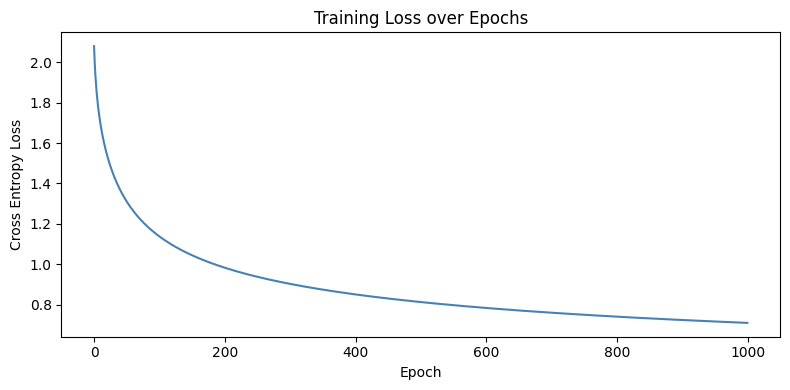

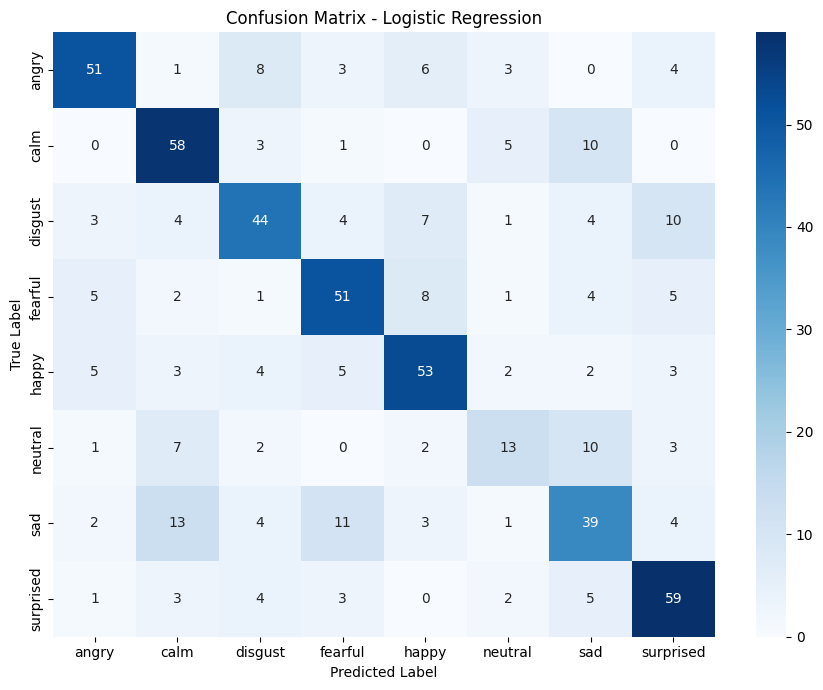

In [8]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(model.losses, color='steelblue')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [9]:
import os

os.makedirs('../models', exist_ok=True)

np.save('../models/lr_weights.npy', model.weights)
np.save('../models/lr_bias.npy', model.bias)
joblib.dump(scaler, '../models/lr_scaler.pkl')
joblib.dump(le, '../models/lr_label_encoder.pkl')

print('Model saved.')

Model saved.
